In [1]:
from mpramnist.Evfratov2017 import EvfratovDataset
from mpramnist.Evfratov2017 import LitModel_Evfratov

from mpramnist.models import HumanLegNet
from mpramnist.models import initialize_weights

import mpramnist.transforms as t

import torch.nn as nn
from torch.utils.data import DataLoader
import lightning.pytorch as L

BATCH_SIZE = 32
NUM_WORKERS = 16

# preprocessing
train_transform = t.Compose([t.ReverseComplement(0.5),t.Seq2Tensor(),])
test_transform = t.Compose([t.Seq2Tensor(),t.ReverseComplement(0),])

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The dataset has a pair of attributes:

**merge_last_classes** — determines whether the last two classes should be merged into one.

**length_of_seq** — determines which dataset to use. "23" refers to the dataset with sequences of length 23, and "33" refers to the dataset with sequences of length 33. The default is "23".


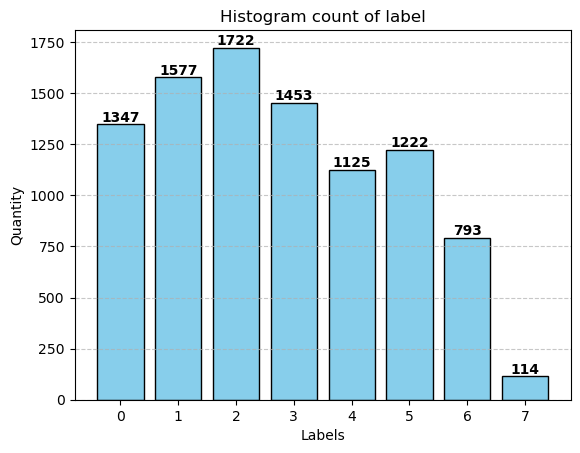

In [2]:
# Merging last 2 classes
merge_last_classes = False

train_dataset = EvfratovDataset(
    split="train",
    merge_last_classes=merge_last_classes,
    length_of_seq=23,  # or 33
    transform=train_transform,
    root="../data/",
)  # use "train" for default training set
# Plot histogram with 8 classes
train_dataset.hist_plot()

# too few examples in group 8

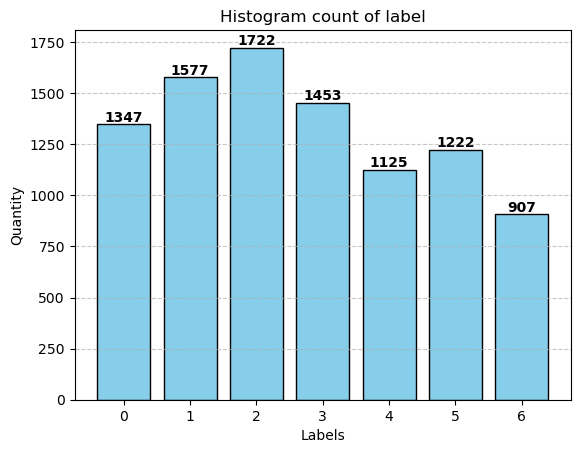

In [3]:
# Therefore, to balance class representation, we propose merging the last two classes into one.
merge_last_classes = True

train_dataset = EvfratovDataset(
    split="train",
    merge_last_classes=merge_last_classes,
    length_of_seq=23,  # or 33
    transform=train_transform,
    root="../data/",
)  # use "train" for default training set
# Plot histogram with 7 classes
train_dataset.hist_plot()

# looks better

In [4]:
# Sequences length of 23
length_of_seq = 23
merge_last_classes = True

train_dataset = EvfratovDataset(split="train",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=train_transform,root="../data/",)  # use "train" for default training set
val_dataset = EvfratovDataset(split="val",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=test_transform,root="../data/",)  # use "val" for default validation set
test_dataset = EvfratovDataset(split="test",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=test_transform,root="../data/",)  # use "test" for default test set

# encapsulate data into dataloader form
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Use train_dataset.n_classes to define number of used classes
N_CLASSES = train_dataset.n_classes
in_channels = len(train_dataset[0][0])

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Epoch 0: 100%|██████████| 293/293 [00:09<00:00, 30.58it/s, v_num=46, train_loss_step=1.610]
| Current_epoch: 0.00000 |


----------------------------------------------------------------------------------------------------
| Precision: 0.26403 | Recall: 0.32588 | Accuracy: 0.28743 | F1: 0.25443 | AUROC: 0.77457 | AUPR: 0.34799 |
----------------------------------------------------------------------------------------------------

Epoch 0: 100%|██████████| 293/293 [00:10<00:00, 27.53it/s, v_num=46, train_loss_step=1.610, val_loss=1.590, val_auroc=0.775, train_loss_epoch=1.730]

Metric val_loss improved. New best score: 1.588


Epoch 1: 100%|██████████| 293/293 [00:08<00:00, 32.69it/s, v_num=46, train_loss_step=1.490, val_loss=1.590, val_auroc=0.775, train_loss_epoch=1.730]
| Current_epoch: 1.00000 |


----------------------------------------------------------------------------------------------------
| Precision: 0.43905 | Recall: 0.35571 | Accuracy: 0.36441 | F1: 0.34950 | AUROC: 0.79824 | AUPR: 0.38088 |
----------------------------------------------------------------------------------------------------

Epoch 1: 100%|██████████| 293/293 [00:10<00:00, 29.18it/s, v_num=46, train_loss_step=1.490, val_loss=1.490, val_auroc=0.798, train_loss_epoch=1.590]

Metric val_loss improved by 0.100 >= min_delta = 0.0. New best score: 1.488


...

Epoch 4: 100%|██████████| 293/293 [00:09<00:00, 30.90it/s, v_num=46, train_loss_step=1.500, val_loss=1.260, val_auroc=0.858, train_loss_epoch=1.370]
| Current_epoch: 4.00000 |


----------------------------------------------------------------------------------------------------
| Precision: 0.52591 | Recall: 0.51565 | Accuracy: 0.50385 | F1: 0.51920 | AUROC: 0.87037 | AUPR: 0.52116 |
----------------------------------------------------------------------------------------------------

Epoch 4: 100%|██████████| 293/293 [00:10<00:00, 27.96it/s, v_num=46, train_loss_step=1.500, val_loss=1.200, val_auroc=0.870, train_loss_epoch=1.280]

Metric val_loss improved by 0.063 >= min_delta = 0.0. New best score: 1.196
`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 293/293 [00:10<00:00, 27.67it/s, v_num=46, train_loss_step=1.500, val_loss=1.200, val_auroc=0.870, train_loss_epoch=1.280]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 37/37 [00:00<00:00, 120.82it/s]
----------------------------------------------------------------------------------------------------
| Precision: 0.51141 | Recall: 0.50390 | Accuracy: 0.50085 | F1: 0.50511 | AUROC: 0.86531 | AUPR: 0.50894 |
----------------------------------------------------------------------------------------------------



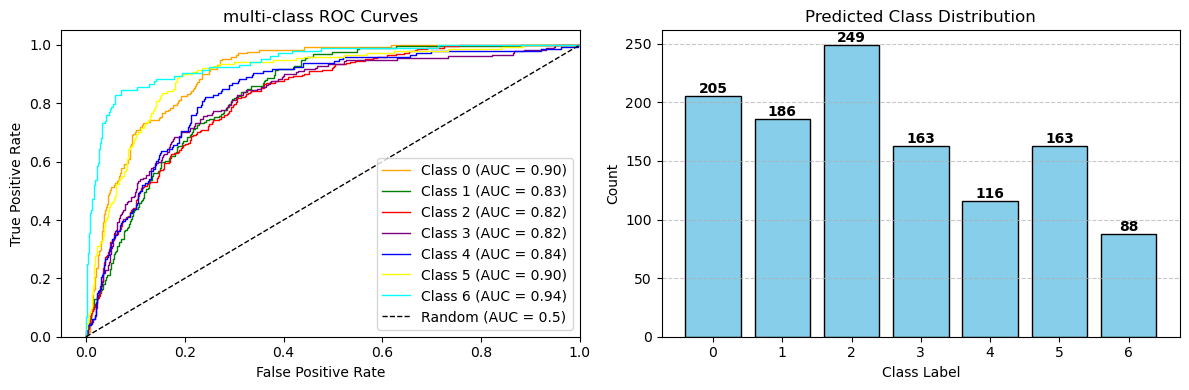

Testing DataLoader 0: 100%|██████████| 37/37 [00:00<00:00, 63.89it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.2331149578094482
        val_aupr             0.508941650390625
        val_auroc           0.8653069734573364
         val_f1             0.5051131248474121
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


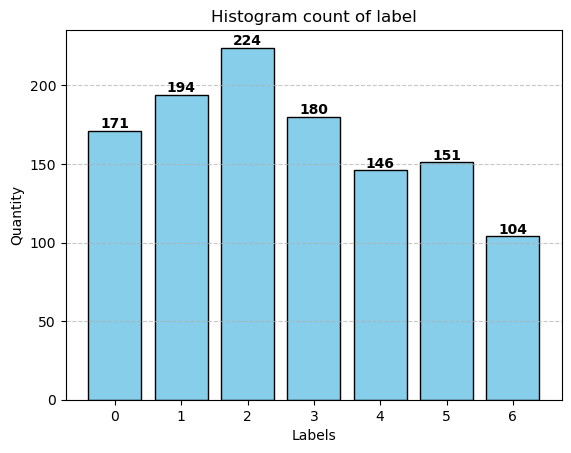

In [5]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=N_CLASSES,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Evfratov(model=model,loss=nn.CrossEntropyLoss(),n_classes=N_CLASSES,weight_decay=1e-1,lr=1e-2,print_each=1)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=5,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

# To see real number of examples in class - plot histogram on test dataset
test_dataset.hist_plot()

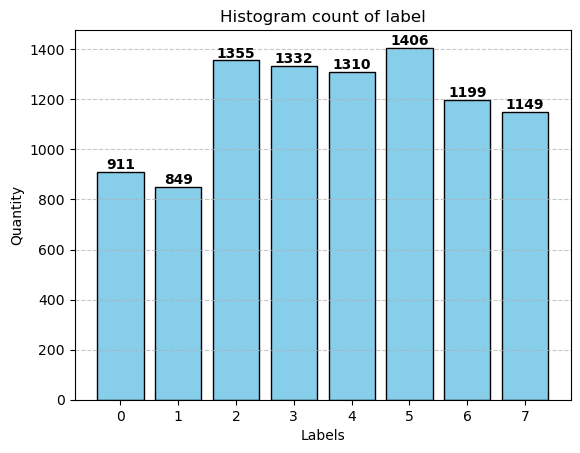

In [6]:
# Sequences length of 33
length_of_seq = 33
merge_last_classes = False

train_dataset = EvfratovDataset(split="train",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=train_transform,root="../data/",)  # use "train" for default training set
val_dataset = EvfratovDataset(split="val",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=test_transform,root="../data/",)  # use "val" for default validation set
test_dataset = EvfratovDataset(split="test",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=test_transform,root="../data/",)  # use "test" for default test set

# encapsulate data into dataloader form
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Use train_dataset.n_classes to define number of used classes
N_CLASSES = train_dataset.n_classes
in_channels = len(train_dataset[0][0])

train_dataset.hist_plot()

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Epoch 0: 100%|██████████| 298/298 [00:09<00:00, 31.57it/s, v_num=47, train_loss_step=2.170]
| Current_epoch: 0.00000 |


----------------------------------------------------------------------------------------------------
| Precision: 0.21110 | Recall: 0.26414 | Accuracy: 0.25820 | F1: 0.19428 | AUROC: 0.73158 | AUPR: 0.28170 |
----------------------------------------------------------------------------------------------------

Epoch 0: 100%|██████████| 298/298 [00:10<00:00, 28.64it/s, v_num=47, train_loss_step=2.170, val_loss=1.880, val_auroc=0.732, train_loss_epoch=1.940]

Metric val_loss improved. New best score: 1.877


Epoch 1: 100%|██████████| 298/298 [00:09<00:00, 32.21it/s, v_num=47, train_loss_step=1.890, val_loss=1.880, val_auroc=0.732, train_loss_epoch=1.940]
| Current_epoch: 1.00000 |


----------------------------------------------------------------------------------------------------
| Precision: 0.34260 | Recall: 0.26168 | Accuracy: 0.27166 | F1: 0.20974 | AUROC: 0.75767 | AUPR: 0.29583 |
----------------------------------------------------------------------------------------------------

Epoch 1: 100%|██████████| 298/298 [00:10<00:00, 28.80it/s, v_num=47, train_loss_step=1.890, val_loss=1.730, val_auroc=0.758, train_loss_epoch=1.820]

Metric val_loss improved by 0.144 >= min_delta = 0.0. New best score: 1.733


...

Epoch 4: 100%|██████████| 298/298 [00:09<00:00, 31.21it/s, v_num=47, train_loss_step=1.100, val_loss=1.470, val_auroc=0.830, train_loss_epoch=1.570]
| Current_epoch: 4.00000 |


----------------------------------------------------------------------------------------------------
| Precision: 0.42229 | Recall: 0.39926 | Accuracy: 0.40622 | F1: 0.38644 | AUROC: 0.83259 | AUPR: 0.41972 |
----------------------------------------------------------------------------------------------------

Epoch 4: 100%|██████████| 298/298 [00:10<00:00, 28.06it/s, v_num=47, train_loss_step=1.100, val_loss=1.470, val_auroc=0.833, train_loss_epoch=1.470]

Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 1.468
`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 298/298 [00:10<00:00, 27.76it/s, v_num=47, train_loss_step=1.100, val_loss=1.470, val_auroc=0.833, train_loss_epoch=1.470]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 38/38 [00:00<00:00, 142.76it/s]
----------------------------------------------------------------------------------------------------
| Precision: 0.39659 | Recall: 0.42504 | Accuracy: 0.44155 | F1: 0.40860 | AUROC: 0.83397 | AUPR: 0.40825 |
----------------------------------------------------------------------------------------------------



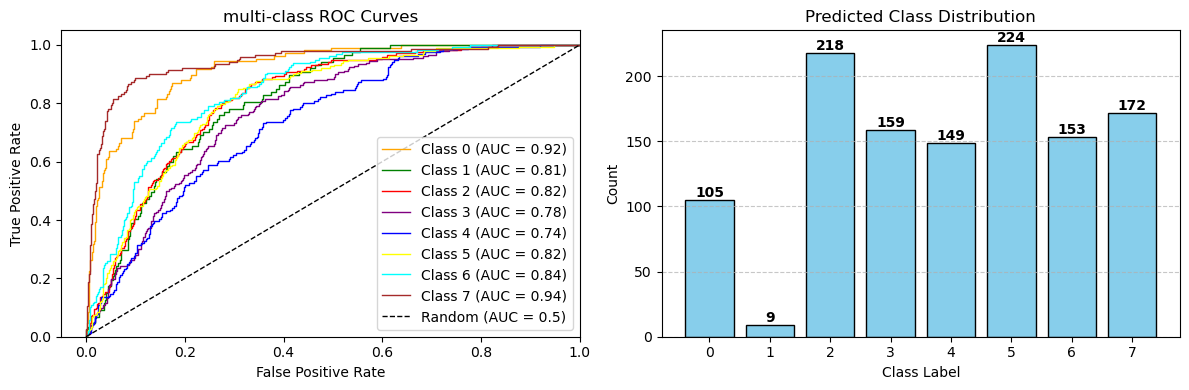

Testing DataLoader 0: 100%|██████████| 38/38 [00:00<00:00, 70.34it/s] 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1.4529669284820557
        val_aupr            0.4082523286342621
        val_auroc            0.833974301815033
         val_f1             0.40860462188720703
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


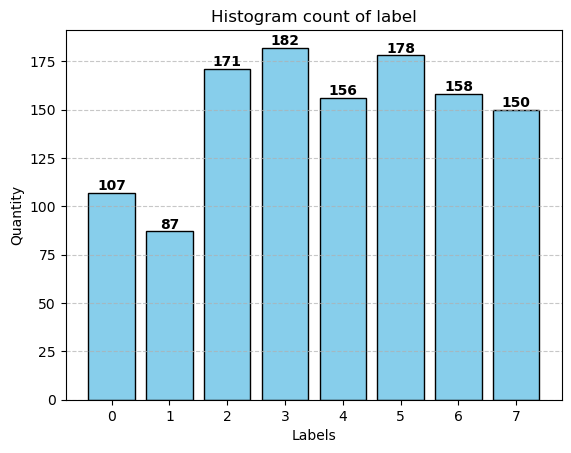

In [7]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=N_CLASSES,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Evfratov(
    model=model,
    loss=nn.CrossEntropyLoss(),
    n_classes=N_CLASSES,
    weight_decay=1e-2,
    lr=1e-2,
    print_each=1,
)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=5,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

# To see real number of examples in class - plot histogram on test dataset
test_dataset.hist_plot()
